# word2vec

앞 장에 이어 이번 장의 주제도 단어의 분산 표현   
앞 장에서는 '통계 기반 기법'으로 단어의 분산 표현을 얻음   
이번 장에서는 더 강력한 기법인 '추론 기반 기법'을 살펴봄   

이름에서 알 수 있듯 '추론 기반 기법'은 추론을 하는 기법   
이 추론 과정에서 신경망을 이용하는데, word2vec를 씀   
이번 장에서는 word2vec의 구조를 들여다보고 구현해보며 확실하게 이해해보고자 함   

이번 장의 목표는 단순한 word2vec 구현하기   
처리 효율을 희생하는 대신 이해하기 쉽도록 구성해서 단순한 word2vec   
따라서 큰 데이터셋까지는 어렵겠지만, 작은 데이터셋이라면 문제없이 처리할 수 있음   
다음 장에서 단순한 word2vec에 몇 가지 개선을 더해 진짜 word2vec을 완성할 예정   

## 추론 기반 기법과 신경망

단어를 벡터로 표현하는 기법은 크게 두 가지로 나눌 수 있음 - '통계 기반 기법'과 '추론 기반 기법'   
단어의 의미를 얻는 방식은 서로 크게 다르지만, 그 배경에는 모두 분포 가설이 있음   

이번 절에서는 통계 기반 기법의 문제를 알아보고, 그 대안인 추론 기반 기법의 이점을 살펴봄   

### 통계 기반 기법의 문제점

통계 기반 기법에서는 주변 단어의 빈도를 기초로 단어를 표현함   
구체적으로는 단어의 동시발생 행렬을 만들고 그 행렬에 SVD를 적용하여 밀집벡터(단어의 분산 표현)을 얻음   
그러나 이 방식은 대규모 말뭉치를 다룰 때 문제가 발생함   

현업에서 다루는 말뭉치의 어휘 수는 어마어마함   
예컨대 영어의 어휘 수는 100만을 훌쩍 넘는다고 함   
어휘가 100만 개라면, 통계 기반 기법에서는 '100만 X 100만'이라는 거대한 행렬을 만들게 됨   
이런 거대 행렬에 SVD를 적용하는 일은 현실적이지 않음   

> SVD를 n X n 행렬에 적용하는 비용은 O(n^3) - 계산 시간이 n의 3제곱에 비례한다는 뜻   
> 이는 슈퍼컴퓨터를 동원해도 처리할 수 없는 수준   
> 실제로는 근사적인 기법과 희소행렬의 성질 등을 이용해 속도를 개선할 수 있지만, 그렇다고 해도 여전히 상당한 컴퓨팅 자원을 들여 장시간 계산 해야 함   

통계 기반 기법은 말뭉치 전체의 통계(동시발생 행렬과 PPMI 등)를 이용해 단 1회의 처리(SVD 등)만에 단어의 분산 표현을 얻음   
한편, 추론 기반 기법에서는, 예컨대 신경망을 이용하는 경우는 미니배치로 학습하는 것이 일반적   
미니배치 학습에서는 신경망이 한 번에 소량(미니배치)의 학습 샘플씩 반복해서 학습하며 가중치를 갱신해감   
아래 그림은 두 기법의 큰 차이를 보여줌   
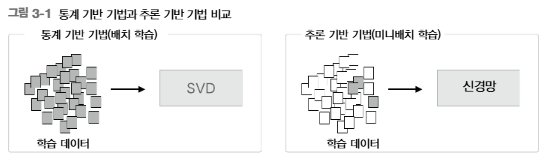   
- 그림처럼 통계 기반 기법은 학습 데이터를 한꺼번에 처리함(배치 학습)   
- 이에 반해 추론 기반 기법은 학습 데이터의 일부를 사용하여 순차적으로 학습함(미니배치 학습)
- 이 말은 말뭉치의 어휘 수가 많아 SVD 등 계산량이 큰 작업을 처리하기 어려운 경우에도 신경망을 학습시킬 수 있다는 뜻 - 데이터를 작게 나눠 학습하기 때문
- 게다가 여러 머신과 여러 GPU를 이용한 병렬 계산도 가능해져서 학습 속도를 높일 수도 있음

### 추론 기반 기법 개요

추론 기반 기법에서는 당연히 '추론'이 주된 작업   
추론이란 아래 그림처럼 주변 단어(맥락)가 주어졌을 때 '?'에 무슨 단어가 들어가는지를 추측하는 작업   
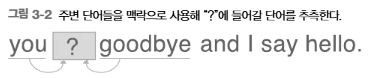   
- 그림처럼 추론 문제를 풀고 학습하는 것이 '추론 기반 기법'이 다루는 문제   
- 이러한 추론 문제를 반복해서 풀면서 단어의 출현 패턴을 학습하는 것   
- '모델 관점'에서 보면, 이 추론 문제는 아래 그림처럼 보임   

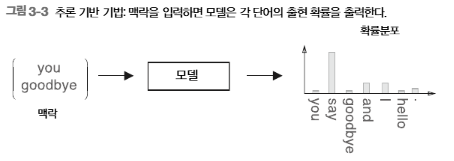   
- 그림처럼 추론 기반 기법에는 어떠한 모델이 등장함
- 여기선 이 모델로 신경망을 사용함
- 모델은 맥락 정보를 입력받아 (출현할 수 있는) 각 단어의 출현 확률을 출력함
- 이러한 틀 안에서 말뭉치를 사용해 모델이 올바른 추측을 내놓도록 학습시킴
- 그리고 그 학습의 결과로 단어의 분산 표현을 얻는 것이 추론 기반 기법의 전체 그림   

> 추론 기반 기법도 통계 기반 기법처럼 분포 가설에 기초함   
> 분포 가설이란 '단어의 의미는 주변 단어에 의해 형성된다'는 가설로, 추론 기반 기법에서는 이를 앞에서와 같은 추측 문제로 귀결시켰음   
> 이처럼 두 기법 모두 분포 가설에 근거하는 '단어의 동시발생 가능성'을 얼마나 잘 모델링하는가가 중요

### 신경망에서의 단어 처리

지금부터 신경망을 이용해 '단어'를 처리   
그런데 신경망은 'you'와 'say' 등의 단어를 있는 그대로 처리할 수 없으니 단어를 '고정 길이의 벡터'로 변환해야 함   
이때 사용하는 대표적인 방법이 단어를 **원핫(one-hot) 표현** (또는 **원핫 벡터**)으로 변환하는 것   
원핫 표현이란 벡터의 원소 중 하나만 1이고 나머지는 모두 0인 벡터를 말함   

원핫 표현에 대해 구체적으로 살펴보면   
여기에서는 앞 장과 같이 "You say goodbye and I say hello."라는 한 문장짜리 말뭉치를 예로 설명   
이 말뭉치에는 어휘가 총 7개 등장함('you', 'say', 'goodbye', 'and', 'i', 'hello', '.')   
이중 두 단어의 원핫 표현을 아래 그림에 나타냈음   
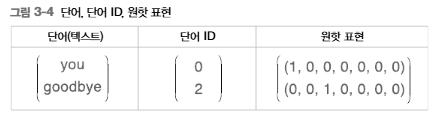   
- 그림처럼 단어는 텍스트, 단어 ID, 그리고 원핫 표현 형태로 나타낼 수 있음
- 여기서 단어를 원핫 표현으로 변환하는 방법은   
- 먼저 총 어휘 수만큼의 원소를 갖는 벡터를 준비하고, 인덱스가 단어 ID와 같은 원소를 1로, 나머지는 모두 0으로 설정함   
- 이처럼 단어를 고정 길이 벡터로 변환하면 신경망의 입력층은 아래 그림처럼 뉴런의 수를 '고정'할 수 있음   

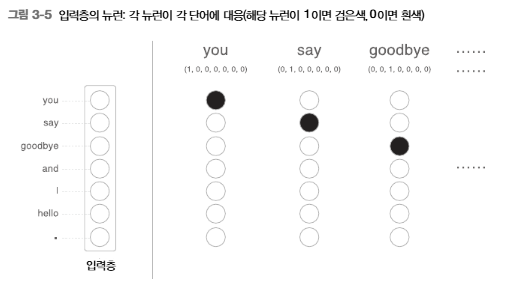   
- 그림처럼 입력층의 뉴런은 총 7개   
- 이 7개의 뉴런은 차례로 7개의 단어들에 대응(첫 번째 뉴런은 'you'에, 두 번째 뉴런은 'say'에, ...)

이제 간단해졌음   
단어를 벡터로 나타낼 수 있고, 신경망을 구성하는 '계층'들은 벡터를 처리할 수 있음   
다시 말해, 단어를 신경망으로 처리할 수 있다는 뜻   
예컨대 아래 그림은 원핫 표현으로 된 단어 하나를 완전연결계층을 통해 변환하는 모습을 보여줌   
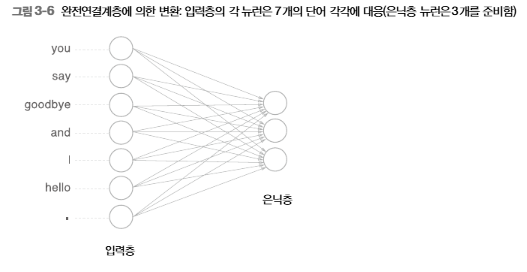   
- 그림의 신경망은 완전연결계층이므로 각각의 노드가 이웃 층의 모든 노드와 화살표로 연결되어 있음   
- 이 화살표에는 가중치(매개변수)가 존재하여, 입력층 뉴런과의 가중합(weighted sum)이 은닉층 뉴런이 됨
- 참고로 이번 장에서 사용하는 완전연결계층에서는 편향을 생략함(이 부분은 뒤의 word2vec 설명 때 이야기할 예정)   

> 편향을 이용하지 않는 완전연결계층은 '행렬 곱' 계산에 해당함   
> 그래서 이 책의 경우, 완전연결계층은 1장에서 구현한 MatMul 계층과 같아짐   
> 참고로 딥러닝 프레임워크들은 일반적으로 완전연결계층을 생성할 때 편향을 이용할지 선택할 수 있도록 해줌   

위에 그림에서는 뉴런 사이의 결합을 화살표로 그렸지만, 이후로는 가중치를 명확하게 보여주기 위해 아래 그림처럼 그릴 예정   
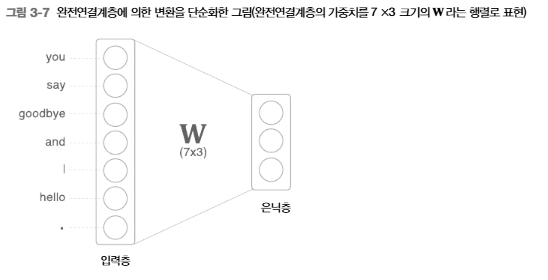   
여기까지를 코드로 살펴보면   
지금의 완전연결계층에 의한 변환은 파이썬으로는 다음과 같음

In [9]:
import numpy as np

c = np.array([[1, 0, 0, 0, 0, 0, 0,]])  # 입력
W = np.random.randn(7, 3)  # 가중치
h = np.matmul(c, W)  # 중간 노드
print(h)

[[ 0.41784205 -0.38784371  0.67706117]]


- 이 코드는 단어 ID가 0인 단어를 원핫 표현으로 표현한 다음 완전연결계층을 통과시켜 변환하는 모습을 보여줌
- 복습해보면, 완전연결계층의 계산은 행렬 곱으로 수행할 수 있고, 행렬 곱은 넘파이의 np.matmul()이 해결해줌 (편향은 생략)   

> 이 코드에서 입력 데이터(c)의 차원 수(ndim)는 2   
> 이는 미니배치 처리를 고려한 것으로, 최초의 차원(0번째 차원)에 각 데이터를 저장함   

위 코드에서 주목할 곳은 c와 W의 행렬곱 부분   
c는 원핫 표현이므로 단어 ID에 대응하는 원소만 1이고 그 외에는 0인 벡터   
따라서 코드의 c와 W의 행렬곱은 결국 아래 그림처럼 가중치의 행벡터 하나를 '뽑아낸' 것과 같음   
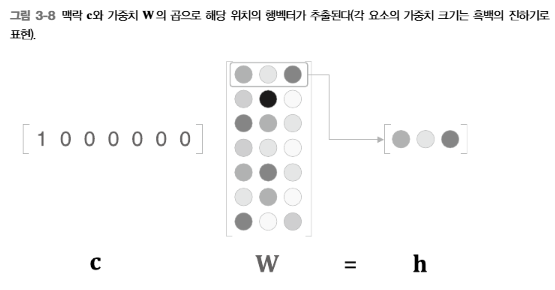   
그저 가중치로부터 행벡터를 뽑아낼 뿐인데 행렬곱을 계산하는 건 비효율적으로 보임 (이 점은 다음 장에서 개선할 예정)   
또한, 위 코드로 수행한 작업은 (1장에서 구현한) MatMul 계층으로도 수행할 수 있음

In [11]:
import sys
sys.path.append('..')
import numpy as np
from common.layers import MatMul

c = np.array([[1, 0, 0, 0, 0, 0, 0]])
W = np.random.randn(7, 3)
layer = MatMul(W)
h = layer.forward(c)
print(h)

[[-0.20697691  0.10958602 -1.73443093]]


- 이 코드는 common 디렉터리에 있는 MatMul 계층을 임포트하여 사용함
- 그런 다음 MatMul 계층에 가중치 W를 설정하고 forward() 메서드를 호출해 순전파를 수행함

## 단순한 word2vec

앞 절에서는 추론 기반 기법을 배우고, 신경망으로 단어를 처리하는 방법을 코드로 살펴봤음   
이것으로 준비는 끝났고 이제 word2vec을 구현할 차례   

지금부터 할 일을 '모델'을 신경망으로 구축하는 것   
이번 절에서 사용할 신경망은 word2vec에서 제안하는 **CBOW(continuous bag-of-words)** 모델   

> word2vec이라는 용어는 원래 프로그램이나 도구를 가리키는 데 사용되었음   
> 그런데 이 용어가 유명해지면서, 문맥에 따라서는 신경망 모델을 가리키는 경우도 많이 볼 수 있음   
> CBOW 모델과 skip-gram 모델은 word2vec에서 사용되는 신경망   
> 이번 절에서는 CBOW 모델을 중심으로 이야기를 풀어가며, 두 모델의 차이는 이후의 절에서 자세히 설명

### CBOW 모델의 추론 처리

CBOW 모델은 맥락으로부터 타깃(target)을 추측하는 용도의 신경망('타깃'은 중안 단어이고 그 주변 단어들이 '맥락')   
여기선 이 CBOW 모델이 가능한 한 정확하게 추론하도록 훈련시켜서 단어의 분산 표현을 얻어낼 것   

CBOW 모델의 입력은 맥락   
맥락은 'you'와 'goodbye' 같은 단어들의 목록   
가장 먼저, 이 맥락을 원핫 표현으로 변환하여 CBOW 모델이 처리할 수 있도록 준비함   
여기까지를 기초로 CBOW 모델의 신경망을 아래 그림처럼 그릴 수 있음   
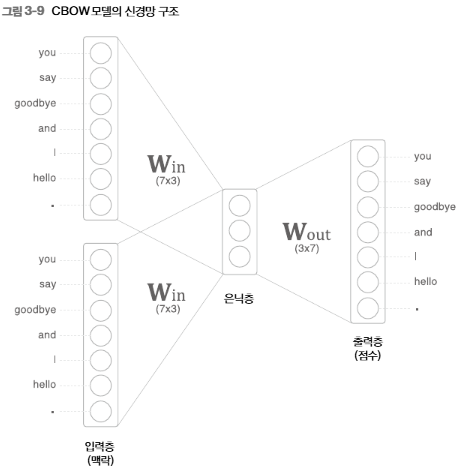   
- 그림이 CBOW 모델의 신경망
- 입력층이 2개 있고, 은닉층을 거쳐 출력층에 도달함
- 두 입력층에서 은닉층으로의 변환은 똑같은 완전연결계층(가중치는 Win)이 처리함
- 그리고 은닉층에서 출력층 뉴런으로의 변환은 다른 완전연결계층(가중치는 Wout)이 처리함   

> 이 그림에서 입력층이 2개인 이유는 맥락으로 고려할 단어를 2개로 정했기 때문   
> 즉, 맥락에 포함시킬 단어가 N개라면 입력층도 N개가 됨   

이제 위 그림의 은닉층에 주목하면   
- 은닉층의 뉴런은 입력층의 완전연결계층에 의해 변환된 값이 되는데, 입력층이 여러개면 전체를 '평균'하면 됨   
- 앞의 예에 대입해보면 다음과 같음   
- 완전연결계층에 의한 첫 번째 입력층이 h1으로 변환되고, 두 번째 입력층이 h2로 변환되었다고 하면, 은닉층 뉴런은 가 되는 것

마지막으로 그림의 출력층을 보면   
- 출력층의 뉴런은 총 7개인데, 여기서 중요한 것은 이 뉴런 하나하나가 각각의 단어에 대응한다는 점
- 그리고 출력층 뉴런은 각 단어의 '점수'를 뜻하며, 값이 높을수록 대응 단어의 출현 확률도 높아짐
- 여기서 점수란 확률로 해석되기 전의 값이고, 이 점수에 소프트맥스 함수를 적용해서 '확률'을 얻을 수 있음   

> 점수를 Softmax 계층에 통한시킨 후의 뉴런을 '출력층'이라고도 함   
> 이 책에서는 점수를 출력하는 노드를 '출력층'이라고 함   

그림처럼 입력층에서 은닉층으로의 변환은 완전연결계층(가중치는 Win)에 의해서 이루어짐   
이때 완전연결계층의 가중치 Win은 7 X 3 행렬이며, 이 가중치가 바로 단어의 분산 표현의 정체   
그림으로 표현하면 아래 그림처럼 됨   
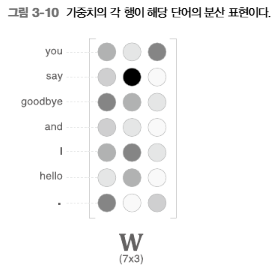   
- 그림에서 보듯 가중치 Win의 각 행에는 해당 단어의 분산 표현이 담겨 있다고 볼 수 있음
- 따라서 학습을 진행할수록 맥락에서 출현하는 단어를 잘 추측하는 방향으로 이 분산 표현들이 갱신될 것
- 그리고 놀랍게도 이렇게 해서 얻은 벡터에는 '단어의 의미'도 잘 녹아들어 있음
- 이것이 word2vec의 전체 그림   

> 은닉층의 뉴런 수를 입력층의 뉴런 수보다 적게 하는 것이 중요한 핵심   
> 이렇게 해야 은닉층에는 단어 예측에 필요한 정보를 '간결하게' 담게 되며, 결과적으로 밀집벡터 표현을 얻을 수 있음   
> 이때 그 은닉층의 정보는 우리 인간은 이해할 수 없는 코드로 쓰여 있음 - '인코딩'에 해당   
> 한편, 은닉층의 정보로부터 원하는 결과를 얻는 작업은 '디코딩'이라고 함   
> 즉, 디코딩이란 인코딩된 정보를 우리 인간이 이해할 수 있는 표현으로 복원하는 작업   

지금까지 CBOW 모델을 '뉴런 관점'에서 그려왔음   
그래서 이번에는 '계층 관점'에서 그려볼 예정   
아래 그림은 위에 그림의 신경망을 계층 관점에서 그린 것   
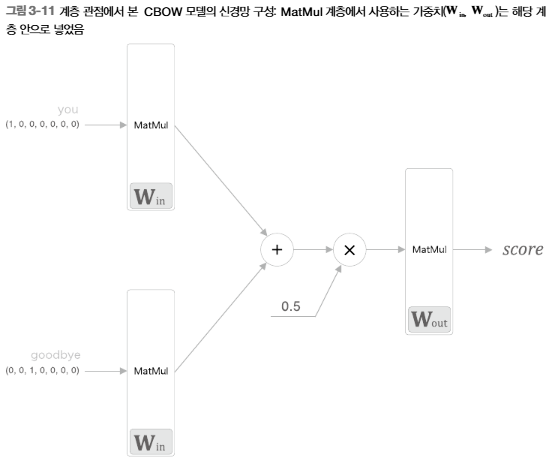   
- 그림에서 알 수 있듯이 CBOW 모델의 가장 앞단에는 2개의 MatMul 계층이 있고, 이어서 이 두 계층의 출력이 더해짐
- 그리고 더해진 값에 0.5를 곱하면 '평균'이 되며, 이 평균이 은닉층 뉴런이 됨
- 마지막으로 은닉층 뉴런에 또 다른 MatMul 계층이 적용되어 '점수(score)'가 출력됨   

> 편향을 사용하지 않는 완전연결계층의 처리는 MatMul 계층의 순전파와 같음   
> MatMul 계층은 내부에서 행렬곱을 계산함   

그럼 위 그림을 참고하여, CBOW 모델의 추론 처리를 파이썬으로 구현해보면 (추론 처리란 '점수'를 구하는 처리를 말함)

In [12]:
import sys
sys.path.append('..')
import numpy as np
from common.layers import MatMul

# 샘플 맥락 데이터
c0 = np.array([[1, 0, 0, 0, 0, 0, 0]])
c1 = np.array([[0, 0, 1, 0, 0, 0, 0]])

# 가중치 초기화
W_in = np.random.randn(7, 3)
W_out = np.random.randn(3, 7)

# 계층 생성
in_layer0 = MatMul(W_in)
in_layer1 = MatMul(W_in)
out_layer = MatMul(W_out)

# 순전파
h0 = in_layer0.forward(c0)
h1 = in_layer1.forward(c1)
h = 0.5 * (h0 + h1)
s = out_layer.forward(h)

print(s)

[[ 0.17560936  0.64276396 -0.53455449 -0.53925988  0.42950797 -1.58081584
   1.59228586]]


- 이 코드에서는 가장 먼저, 필요한 가중치들(W_in과 W_out)을 초기화함
- 그리고 입력층을 처리하는 MatMul 계층을 맥락 수만큼 (여기에서는 2개) 생성하고, 출력층 측의 MatMul 계층은 1개만 생성함
- 이때 입력층 측의 MatMul 계층은 가중치 W_in을 공유한다는 점에 주의   
- 다음은 입력층 측의 MatMul 계층들(in_layer0과 in_layer1)의 forward() 메서드를 호출해 중간 데이터를 계산하고, 
- 출력층 측의 MatMul 계층(out_layer)을 통과시켜 각 단어의 점수를 구함

여기까지가 CBOW 모델의 추론 과정   
여기서 보았듯이 CBOW 모델은 활성화 함수를 사용하지 않는 간단한 구성의 신경망   
입력층이 여러 개 있고, 그 입력층들이 가중치를 공유한다는 점을 제외하면 어려운 부분은 없음   
계속해서 CBOW 모델의 학습에 대해 알아봄

### CBOW 모델의 학습

지금까지 설명한 CBOW 모델은 출력층에서 각 단어의 점수를 출력했음   
이 점수에 소프트맥스 함수를 적용하면 '확률'을 얻을 수 있음   
이 확률은 맥락(전후 단어)이 주어졌었을 때 그 중앙에 어떤 단어가 출현하는지를 나타냄   

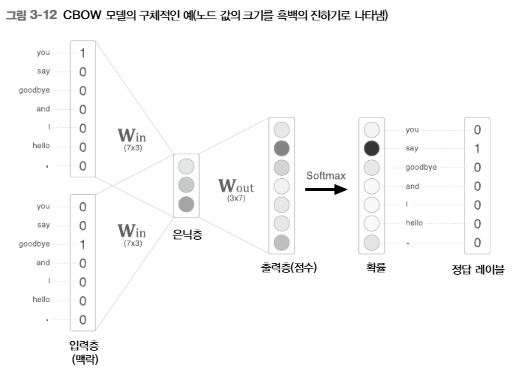   
- 그림의 예에서 맥락은 'you'와 'goodbye'이고, 정답 레이블(신경망이 예측해야 할 단어)은 'say'
- 이때 '가중치가 적절히 설정된' 신경망이라면 '확률'을 나타내는 뉴런들 중 정답에 해당하는 뉴런의 값이 클 것이라 기대할 수 있음   

CBOW 모델의 학습에서는 올바른 예측을 할 수 있도록 가중치를 조정하는 일을 함   
그 결과로 가중치 Win에(정확하게는 Win과 Wout 모두에) 단어의 출현 패턴을 파악한 벡터가 학습됨   
그리고 지금까지의 실험에 의해 CBOW 모델(과 skip-gram 모델)로 얻을 수 있는 단어의 분산 표현은 단어의 의미 면에서나 문법 면에서 모두 사람 직관에 부합하는 경우를 많이 볼 수 있음   
(위키백과 등의 대규모 말뭉치를 사용해 얻을 수 있는 단어의 분산 표현이라면 더욱 그럼)   

> CBOW 모델은 단어 출현 패턴을 학습 시 사용한 말뭉치로부터 배움   
> 따라서 말뭉치가 다르면 학습 후 얻게 되는 단어의 분산 표현도 달라짐   
> 예컨대 말뭉치로 '스포츠' 기사만을 사용하는 경우와 '음악' 관련 기사만을 사용하는 경우는 얻게 되는 단어의 분산 표현이 크게 다를 것   

다시 앞에서 본 신경망의 학습에 대해 생각해보면   
여기서 다루고 있는 모델은 다중 클래스 분류를 수행하는 신경망   
따라서 이 신경망을 학습하려면 소프트맥스와 교차 엔트로피 오차만 이용하면 됨   
여기에서는 소프트맥스 함수를 이용해 점수를 확률로 변환하고, 그 확률과 정답 레이블로부터 교차 엔트로피 오차를 구한 후, 그 값을 손실로 사용해 학습을 진행함   
그림으로는   
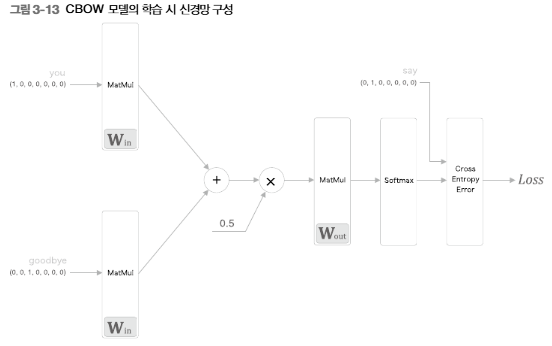   
- 그림에서 보듯, 앞 절에서 설명한 추론 처리를 수행하는 CBOW 모델에 Softmax 계층과 Cross Entropy Error 계층을 추가했을 뿐 - 이것만으로 손실을 얻을 수 있음   
- 여기까지 CBOW 모델의 손실을 구하는 계산의 흐름이자, 이 신경망의 순방향 전파   

덧붙여 그림에서는 Softmax 계층과 Cross Entropy Error 계층을 사용했지만, 이 두 계층을 Softmax with Loss라는 하나의 계층으로 구현할 것   
따라서 앞으로 구현할 신경망의 정확한 모습은 아래 그림처럼 생겼음   
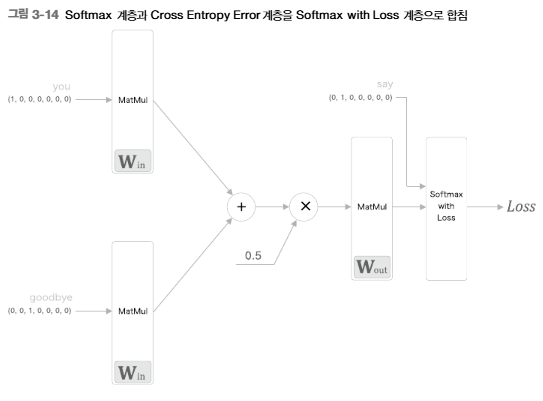   

### word2vec의 가중치와 분산 표현

지금까지 설명한 것처럼 word2vec에서 사용되는 신경망에는 두 가지 가중치가 있음   
입력 측 완전연결계층의 가중치(Win)와 출력 측 완전연결계층의 가중치(Wout)   
그리고 입력 측 가중치 Win의 각 행이 각 단어의 분산 표현에 해당   
또한 출력 측 가중치 Wout에도 단어의 의미가 인코딩된 벡터가 저장되고 있다고 생각할 수 있음   
다만, 출력 측 가중치는 아래 그림에서 보듯 각 단어의 분산 표현이 열 방향(수직 방향)으로 저장됨   
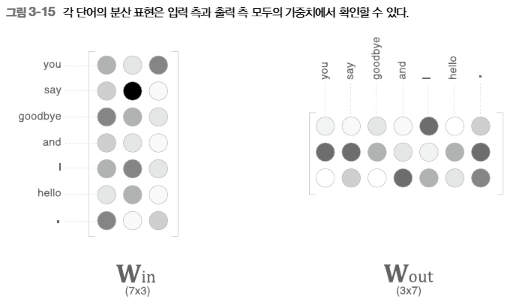   

그러면 최종적으로 이용하는 단어의 분산 표현으로는 어느 쪽 가중치를 선택하면 좋을지
1. 입력 측의 가중치만 이용
2. 출력 측의 가중치만 이용
3. 양쪽 가중치를 모두 이용   

1번과 2번은 어느 한쪽 가중치만 이용한다는 것   
3번은 두 가중치를 어떻게 조합하느냐에 따라 다시 몇 가지 방법을 생각해낼 수 있음   
그중 하나는 두 가중치를 단순히 합치는 것   

word2vec(특히 skip-gram 모델)에서는 1번인 '입력 측의 가중치만 이용'이 가장 대중적인 선택   
많은 연구에서 출력 측 가중치는 버리고 입력 측 가중치 Win만을 최종 단어의 분산 표현으로서 이용함   
여기에서도 이를 따라서 Win을 단어의 분산 표현으로 이용할 것   

## 학습 데이터 준비

지금부터 word2vec 학습에 쓰일 학습 데이터를 준비함   
이번에도 간단한 예로서 지금까지처럼 "You say goodbye and I say hello."라는 한 문장짜리 말뭉치를 이용

### 맥락과 타깃

word2vec에서 이용하는 신경망의 입력은 '맥락'   
그리고 그 정답 레이블은 맥락에 둘러싸인 중앙의 단어, 즉 '타깃'   
다시 말해, 해야 할 일은 신경망에 '맥락'을 입력했을 때 '타깃'이 출현할 확률을 높이는 것(그렇게 되도록 학습시킬 것)   

그럼 말뭉치에서 '맥락'과 '타깃'을 만드는 작업을 생각해보면   
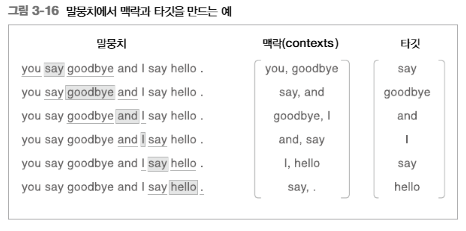   
- 그림에서는 말뭉치로부터 목표로 하는 단어를 '타깃'으로, 그 주변 단어를 '맥락'으로 뽑아냈음
- 이 작업을 말뭉치 안의 (양끝 단어는 제외한) 모든 단어에 대해 수행함
- 이렇게 만들어진 것이 그림의 오른쪽에 있는 '맥락'과 '타깃' 
- 이 맥락의 각 행이 신경망의 입력으로 쓰이고, 타깃의 각 행이 정답 레이블(예측해야 하는 단어)이 됨
- 참고로, 각 샘플 데이터에서 맥락의 수는 여러 개(이 예에서는 2개)가 될 수 있으나, 타깃은 오직 하나뿐
- 그래서 맥락을 영어로 쓸 때는 끝에 's'를 붙여 복수형임을 명시하는 게 좋음   

곧이어 말뭉치로부터 맥락과 타깃을 만드는 함수를 구현할 것   
그전에 앞 장의 내용을 살짝 복습해보면   
우선 말뭉치 텍스트를 단어 ID로 변환해야함   
이 작업에는 2장에서 구현한 preprocess() 함수를 사용

In [14]:
import sys
sys.path.append('..')
from common.util import preprocess

text = 'You say goodbye and I say hello.'
corpus, word_to_id, id_to_word = preprocess(text)
print(corpus)
print(id_to_word)

[0 1 2 3 4 1 5 6]
{0: 'you', 1: 'say', 2: 'goodbye', 3: 'and', 4: 'i', 5: 'hello', 6: '.'}


- 그런 다음 단어 ID의 배열인 corpus로부터 맥락과 타깃을 만들어냄
- 구체적으로는 아래 그림처럼 corpus를 주면 맥락과 타깃을 반환하는 함수를 작성함   

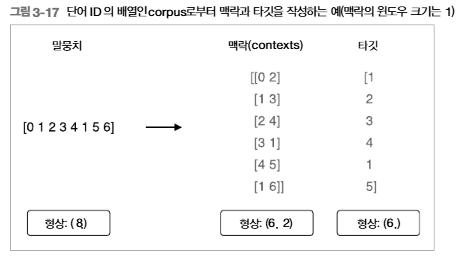   
- 그림과 같이 맥락은 2차원 배열
- 이때 맥락의 0번째 차원에는 각 맥락 데이터가 저장됨
- 정확하게 말하면, contexts[0]에는 0번째 맥락이 저장되고, contexts[1]에는 1번째 맥락이 저장되는 식
- 마찬가지로 타깃에서도 target[0]에는 0번째 타깃이, target[1]에는 1번째 타깃이 저장됨   

다음은 이 맥락과 타깃을 만드는 함수를 구현할 차례   
create_contexts_target(corpus, window_size)라는 이름으로 다음과 같이 구현

In [15]:
def create_contexts_target(corpus, window_size=1):
    target = corpus[window_size:-window_size]
    contexts = []

    for idx in range(window_size, len(corpus)-window_size):
        cs = []
        for t in range(-window_size, window_size + 1):
            if t == 0:
                continue
            cs.append(corpus[idx + t])
        contexts.append(cs)

    return np.array(contexts), np.array(target)

- 이 함수는 인수를 두 개 받음
- 하나는 단어 ID의 배열(corpus), 다른 하나는 맥락의 윈도우 크기(window_size)
- 그리고 맥락과 타깃을 각각 넘파이 다차원 배열로 돌려줌   

이 함수를 실제로 사용해보면

In [16]:
contexts, target = create_contexts_target(corpus, window_size=1)

print(contexts)
print(target)

[[0 2]
 [1 3]
 [2 4]
 [3 1]
 [4 5]
 [1 6]]
[1 2 3 4 1 5]


- 이것으로 말뭉치로부터 맥락과 타깃을 만들어냈음
- 나중에 이를 CBOW 모델에 넘겨주면 됨   

그런데 이 맥락과 타깃의 각 원소는 여전히 단어 ID   
그럼 이어서 이를 원핫 표현으로 변환

### 원핫 표현으로 변환

계속해서 맥락과 타깃을 원핫 표현으로 바꿔보면   
이때 수행하는 변환은 아래 그림과 같음   
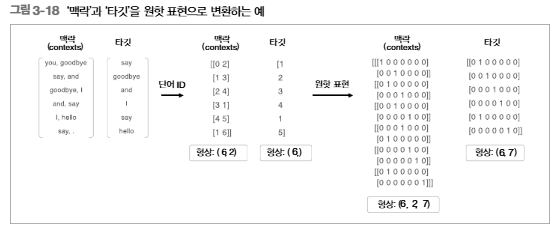   
- 그림의 예처럼 맥락과 타깃을 단어 ID에서 원핫 표현으로 변환하면 됨
- 이때 다시 한번 각각의 다차원 배열의 형상에 주목해야 함
- 잘 보면, 이 그림에서는 단어 ID를 이용했을 때의 맥락의 형상은 (6, 2)인데, 이를 원핫 표현으로 변환하면 (6, 2, 7)이 됨   

원핫 표현으로의 변환은 이 책이 제공하는 convert_one_hot() 함수를 사용   
이 함수는 인수로 '단어 ID 목록'과 '어휘 수'를 받음

In [18]:
def convert_one_hot(corpus, vocab_size):
    N = corpus.shape[0]

    if corpus.ndim == 1:
        one_hot = np.zeros((N, vocab_size), dtype=np.int32)
        for idx, word_id in enumerate(corpus):
            one_hot[idx, word_id] = 1

    elif corpus.ndim == 2:
        C = corpus.shape[1]
        one_hot = np.zeros((N, C, vocab_size), dtype=np.int32)
        for idx_0, word_ids in enumerate(corpus):
            for idx_1, word_id in enumerate(word_ids):
                one_hot[idx_0, idx_1, word_id] = 1

    return one_hot

그럼 지금까지의 데이터 준비 과정을 한 데 모아 정리해보면

In [19]:
import sys
sys.path.append('..')
from common.util import preprocess, create_contexts_target, convert_one_hot

text = 'You say goodbye and I say hello.'
corpus, word_to_id, id_to_word = preprocess(text)

contexts, target = create_contexts_target(corpus, window_size=1)

vocab_size = len(word_to_id)
target = convert_one_hot(target, vocab_size)
contexts = convert_one_hot(contexts, vocab_size)

이것으로 학습 데이터 준비를 마침   
다음은 본론인 CBOW 모델 구현

## CBOW 모델 구현

구현할 신경망은 아래 그림과 같음   
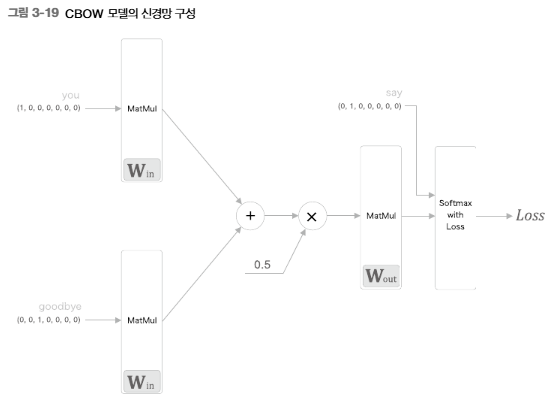   
- 여기서는 그림의 신경망을 SimpleCBOW라는 이름으로 구현할 것(다음 장에서는 이를 개선한 CBOW 클래스를 구현)   

SimpleCBOW 클래스의 초기화 메서드부터 시작해보면

In [21]:
import sys
sys.path.append('..')
import numpy as np
from common.layers import MatMul, SoftmaxWithLoss

class SimpleCBOW:
    def __init__(self, vocab_size, hidden_size):
        V, H = vocab_size, hidden_size

        # 가중치 초기화
        W_in = 0.01 * np.random.randn(V, H).astype('f')
        W_out = 0.01 * np.random.randn(H, V).astype('f')

        # 계층 생성
        self.in_layer0 = MatMul(W_in)
        self.in_layer1 = MatMul(W_in)
        self.out_layer = MatMul(W_out)
        self.loss_layer = SoftmaxWithLoss()

        # 모든 가중치와 기울기를 리스트에 모음
        layers = [self.in_layer0, self.in_layer1, self.out_layer]
        self.params, self.grads = [], []
        for layer in layers:
            self.params += layer.params
            self.grads += layer.grads

        # 인스턴스 변수에 단어의 분산 표현을 저장
        self.word_vecs = W_in

- 이 초기화 메서드는 인수로 어휘 수(vocab_size)와 은닉층의 뉴런 수(hidden_size)를 받음
- 가중치 초기화 부분에서는 가중치를 2개 생성(W_in과 W_out)
    - 이 두 가중치는 각각 작은 무작위 값으로 초기화됨
    - 그리고 이때 넘파이 배열의 데이터 타입을 astype('f')로 지정 - 즉, 32비트 부동소수점 수로 초기화   
- 이어서 필요한 계층을 생성
    - 입력 측의 MatMul 계층을 2개, 출력 측의 MatMul 계층을 하나, 그리고 Softmax with Loss 계층을 하나 생성
    - 여기서 입력 측의 맥락을 처리하는 MatMul 계층은 맥락에서 사용하는 단어의 수(윈도우 크기)만큼 만들어야 함(이 예에서는 2개)
    - 그리고 입력 측 MatMul 계층들은 모두 같은 가중치를 이용하도록 초기화
- 마지막으로 이 신경망에서 사용되는 매개변수와 기울기를 인스턴스 변수인 params와 grads 리스트에 각각 모아둠   

> 이 코드에서는 여러 계층에서 같은 가중치를 공유하고 있음   
> 따라서 params 리스트에는 같은 가중치가 여러 개 존재하게 되는데, 이렇게 되면 Adam이나 Momentum 등의 옵티마이저 처리가 본래의 동작과 달라져버림(적어도 지금 구현에서는)   
> 그래서 Trainer 클래스 내부에서는 매개변수를 갱신할 때 매개변수의 중복을 없애는 간단한 작업을 수행하도록 함   
> common/trainer.py의 remove_duplicate(params, grads) 함수   

이어서 신경망의 순전파인 forward() 메서드를 구현   
이 메서드는 인수로 맥락(contexts)과 타깃(target)을 받아 손실(loss)을 반환

In [22]:
def forward(self, contexts, target):
    h0 = self.in_layer0.forward(contexts[:, 0])
    h1 = self.in_layer1.forward(contexts[:, 1])
    h = (h0 + h1) * 0.5
    score = self.out_layer.forward(h)
    loss = self.loss_layer.forward(score, target)
    return loss

- 여기서 인수 contexts는 3차원 넘파이 배열이라고 가정
- 이전 그림의 예에서라면 이 배열의 형상은 (6, 2, 7)이 됨
- 그 0번째 차원의 원소 수는 미니배치의 수만큼이고, 1번째 차원의 원소 수는 맥락의 윈도우 크기, 2번째 차원은 원핫 벡터
- 또한, target의 형상은 2차원으로, 예컨대 (6, 7)과 같은 형상이 됨   

마지막으로 전파인 backward()를 구현   
이 역전파의 계산 그래프는 아래 그림과 같음   
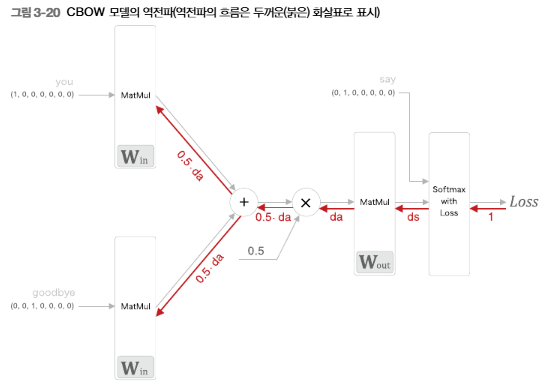   
- 신경망의 역전파는 기울기를 순전파 때와는 반대 방향으로 전파함
- 이 역전파는 '1'에서 시작하여 곧바로 Softmax with Loss 계층에 입력됨
- 그리고 Softmax with Loss 계층의 역전파 출력이 ds이며, 이 ds를 출력 측 MatMul 계층으로 입력함
- 그런 다음 'X'와 '+' 연산으로 역전파됨
- 'X'의 역전파는 순전파 시의 입력을 '서로 바꿔' 기울기에 곱함
- '+'의 역전파는 기울기를 '그대로 통과'시킴   

그러면 그림의 역전파를 구현해보면

In [23]:
def backward(self, dout=1):
    ds = self.loss_layer.backward(dout)
    da = self.out_layer.backward(ds)
    da *= 0.5
    self.in_layer1.backward(da)
    self.in_layer0.backward(da)
    return None

이것으로 역전파 구현까지 모두 마침   

전에 이미 각 매개변수의 기울기를 인스턴스 변수 grads에 모아뒀음   
따라서 forward() 메서드를 호출한 다음 backward() 메서드를 실행하는 것만으로 grads 리스트의 기울기가 갱신됨   

In [25]:
import sys
sys.path.append('..')
import numpy as np
from common.layers import MatMul, SoftmaxWithLoss


class SimpleCBOW:
    def __init__(self, vocab_size, hidden_size):
        V, H = vocab_size, hidden_size

        # 가중치 초기화
        W_in = 0.01 * np.random.randn(V, H).astype('f')
        W_out = 0.01 * np.random.randn(H, V).astype('f')

        # 계층 생성
        self.in_layer0 = MatMul(W_in)
        self.in_layer1 = MatMul(W_in)
        self.out_layer = MatMul(W_out)
        self.loss_layer = SoftmaxWithLoss()

        # 모든 가중치와 기울기를 리스트에 모음
        layers = [self.in_layer0, self.in_layer1, self.out_layer]
        self.params, self.grads = [], []
        for layer in layers:
            self.params += layer.params
            self.grads += layer.grads

        # 인스턴스 변수에 단어의 분산 표현을 저장
        self.word_vecs = W_in

    def forward(self, contexts, target):
        h0 = self.in_layer0.forward(contexts[:, 0])
        h1 = self.in_layer1.forward(contexts[:, 1])
        h = (h0 + h1) * 0.5
        score = self.out_layer.forward(h)
        loss = self.loss_layer.forward(score, target)
        return loss

    def backward(self, dout=1):
        ds = self.loss_layer.backward(dout)
        da = self.out_layer.backward(ds)
        da *= 0.5
        self.in_layer1.backward(da)
        self.in_layer0.backward(da)
        return None

### 학습 코드 구현

CBOW 모델의 학습은 일반적인 신경망의 학습과 완전히 같음   
학습 데이터를 준비해 신경망에 입력한 다음, 기울기를 구하고 가중치 매개변수를 순서대로 갱신해갈 것   
1장에서 설명한 Trainer 클래스를 이번 학습 과정을 수행하는 데 이용할 것   

다음은 학습을 위한 코드

| 에폭 1 |  반복 1 / 2 | 시간 0[s] | 손실 1.95
| 에폭 2 |  반복 1 / 2 | 시간 0[s] | 손실 1.95
| 에폭 3 |  반복 1 / 2 | 시간 0[s] | 손실 1.95
| 에폭 4 |  반복 1 / 2 | 시간 0[s] | 손실 1.95
| 에폭 5 |  반복 1 / 2 | 시간 0[s] | 손실 1.95
| 에폭 6 |  반복 1 / 2 | 시간 0[s] | 손실 1.95
| 에폭 7 |  반복 1 / 2 | 시간 0[s] | 손실 1.95
| 에폭 8 |  반복 1 / 2 | 시간 0[s] | 손실 1.95
| 에폭 9 |  반복 1 / 2 | 시간 0[s] | 손실 1.95
| 에폭 10 |  반복 1 / 2 | 시간 0[s] | 손실 1.95
| 에폭 11 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 12 |  반복 1 / 2 | 시간 0[s] | 손실 1.95
| 에폭 13 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 14 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 15 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 16 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 17 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 18 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 19 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 20 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 21 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 22 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 23 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 24 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 25 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 26 |

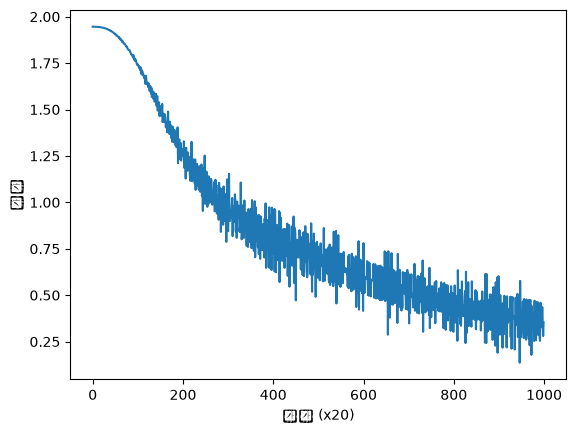

In [27]:
import sys
sys.path.append('..')  # 부모 디렉터리의 파일을 가져올 수 있도록 설정
from common.trainer import Trainer
from common.optimizer import Adam
from common.util import preprocess, create_contexts_target, convert_one_hot


window_size = 1
hidden_size = 5
batch_size = 3
max_epoch = 1000

text = 'You say goodbye and I say hello.'
corpus, word_to_id, id_to_word = preprocess(text)

vocab_size = len(word_to_id)
contexts, target = create_contexts_target(corpus, window_size)
target = convert_one_hot(target, vocab_size)
contexts = convert_one_hot(contexts, vocab_size)

model = SimpleCBOW(vocab_size, hidden_size)
optimizer = Adam()
trainer = Trainer(model, optimizer)

trainer.fit(contexts, target, max_epoch, batch_size)
trainer.plot()

- 매개변수 갱신 방법으로는 SGD와 AdaGrad 같은 알고리즘이 있는데 이 코드에서는 그 중 Adam을 선택함
- 바로 이어 등장하는 Trainer 클래스는 1장에서 설명한 방식으로 신경망을 학습시킴
- 즉, 학습 데이터로부터 미니배치를 선택한 다음, 신경망에 입력해 기울기를 구하고, 그 기울기를 Optimizer에 넘겨 매개변수를 갱신하는 일련의 작업을 수행   

> 앞으로도 신경망 학습에는 Trainer 클래스를 이용함   
> Trainer 클래스를 이용하면 자칫 복잡해지기 쉬운 학습 코드를 깔끔하게 유지할 수 있기 때문   

위 코드의 실행 결과는 다음과 같음   
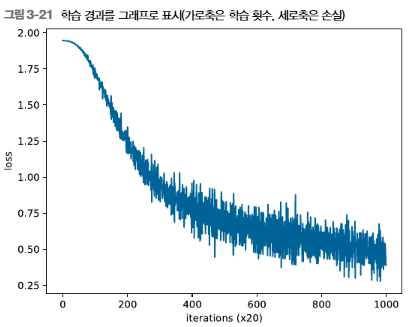   
- 보다시피 학습을 거듭할수록 손실이 줄어드는 것을 알 수 있음 - 학습이 순조롭게 이루어짐   

그러면 학습이 끝난 후의 가중치 매개변수를 살펴보면   
입력 측 MatMul 계층의 가중치를 꺼내 실제 내용을 확인   
입력 측 MatMul 계층의 가중치는 인스턴스 변수 word_vecs에 저장돼 있으니, 앞의 코드 바로 뒤에 다음 코드를 추가

In [28]:
word_vecs = model.word_vecs
for word_id, word in id_to_word.items():
    print(word, word_vecs[word_id])

you [ 1.2548102   0.903288   -0.8996617   0.75022525 -1.7134433 ]
say [ 1.31941    -1.1521895   1.1436785  -1.146069    0.23487651]
goodbye [ 0.69723845  1.1001359  -1.0718852   1.2155907   0.39172417]
and [ 1.19892    -0.8257991   0.76954585 -0.8387932   1.7965382 ]
i [ 0.7013038  1.0977615 -1.0778316  1.2230872  0.3860606]
hello [ 1.2584589   0.89920527 -0.8924439   0.76654893 -1.6995726 ]
. [ 1.0758444 -1.1189018  1.1654592 -1.1078348 -1.6278793]


- 이 코드는 word_vecs라는 이름으로 가중치를 꺼내는데, word_vecs의 각 행에는 대응하는 단어 ID의 분산 표현이 저장되어 있음   

마침내 단어를 밀집벡터로 나타낼 수 있게 되었음 - 이 밀집벡터가 바로 단어의 분산 표현   
학습이 잘 이뤄졌으니 이 분산 표현은 '단어의 의미'를 잘 파악한 벡터 표현으로 되어 있을 것이라 기대할 수 있음   

하지만 아쉽게도 여기서 다룬 작은 말뭉치로는 좋은 결과를 얻을 수 없음   
이유는 당연히 말뭉치가 워낙 작기 때문   
실용적이고 충분히 큰 말뭉치로 바꾸면 결과도 그만큼 좋아지겠지만, 처리 속도 면에서 문제가 생김   

현시점의 CBOW 모델 구현은 처리 효율 면에서 몇 가지 문제가 있음   
그래서 4장에서는 현재의 '단순한' CBOW 모델을 개선하여 '진짜' CBOW 모델을 구현할 계획

## word2vec 보충

지금까지 word2vec의 CBOW 모델을 자세히 살펴봤음   
이번 절에서는 지금까지 살피지 못한 word2vec에 관한 중요한 주제 몇 개를 보충   
우선은 CBOW 모델을 '확률' 관점에서 다시 살펴봄

### CBOW 모델과 확률

먼저 '확률'의 표기법을 간단하게 설명   
이 책에서는 확률을 P(·)처럼 씀   
예컨대 A라는 현상이 일어날 확률은 P(A)라고 씀   

또, **동시 확률** 은 P(A, B)로 씀   
동시 확률이란 'A와 B가 동시에 일어날 확률'을 말함   

**사후 확률** 은 P(A|B)로 씀   
이는 말 그대로 '사건이 일어난 후의 확률'   
'B(라는 정보)가 주어졌을 때 A가 일어날 확률'이라고도 해석할 수 있음   

그럼 CBOW 모델을 확률 표기법으로 기술해봄   
CBOW 모델이 하는 일은 맥락을 주면 타깃 단어가 출현할 확률을 출력하는 것   
여기에서는 말뭉치를 w1, w2, ..., wT처럼 단어 시퀀스로 표기하고, 아래 그림처럼 t번째 단어에 대해 윈도우 크기가 1인 맥락을 가정함   
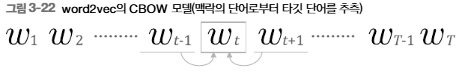   

그럼 맥락으로 wt-1과 wt+1이 주어졌을 때 타깃이 wt가 될 확률은 수식으로   
사후 확률을 사용해 아래 식처럼 쓸 수 있음   
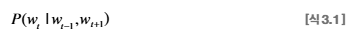   
- 식은 'wt-1과 wt+1이 일어난 후 wt가 일어날 확률'을 뜻함
- 그리고 'wt-1과 wt+1이 주어졌을 때 wt가 일어날 확률'로 해석할 수 있음
- 즉, CBOW는 위 식을 모델링하고 있는 것   

위 식을 이용하면 CBOW 모델의 손실 함수도 간결하게 표현할 수 있음   
1장에서 설명한 교차 엔트로피 오차를 적용해보면   

교차 엔트로피 오차 식은 였으며,   
이때 yk는 'k번째에 해당하는 사건이 일어날 확률'을 말함   
그리고 tk는 정답 레이블이며 원핫 벡터로 표현됨   
여기서 문제의 정답은 'wt가 발생'이므로 wt에 해당하는 원소만 1이고 나머지는 0이 됨(즉, wt 이외의 일이 일어날 경우에 대해서는 해당 원핫 레이블의 요소는 0이 됨)   
이 점을 감안하면 다음 식을 유도해낼 수 있음   
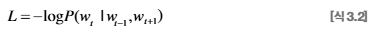   
- 이 식에서 보듯, CBOW 모델의 손실 함수는 단순히 사후 확률에 log를 취한 다음 마이너스를 붙이면 됨
- 참고로, 이를 **음의 로그 가능도(negative log likelihood)** 라 함   
- 덧붙여 이 식은 샘플 데이터 하나에 대한 손실 함수이며, 이를 말뭉치 전체로 확장하면 다음 식이 됨   

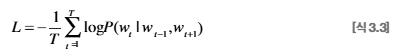   
- CBOW 모델의 학습이 수행하는 일은 이 손실 함수의 값을 가능한 한 작게 만드는 것
- 그리고 이때의 가중치 매개변수가 우리가 얻고자 하는 단어의 분산 표현인 것
- 여기에서는 윈도우 크기가 1인 경우만 생각했지만, 다른 크기(또는 m 등의 범용적인 크기)라 해도 수식으로 쉽게 나타낼 수 있음

### skip-gram 모델

앞에서도 언급했듯이 word2vec은 2개의 모델을 제안하고 있음   
하나는 지금까지 본 CBOW 모델이고, 다른 하나는 skip-gram 모델   
skip-gram은 CBOW에서 다루는 맥락과 타깃을 역전시킨 모델   

구체적인 예를 보면 아래 그림은 이 두 모델이 다루는 문제를 보여줌   
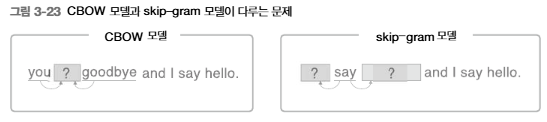   
- 그림과 같이 CBOW 모델은 맥락이 여러 개 있고, 그 여러 맥락으로부터 중앙의 단어(타깃)를 추측함
- 한편, skip-gram 모델은 중앙의 단어(타깃)로부터 주변의 여러 단어(맥락)를 추측함
- 이 그림의 skip-gram 모델의 신경망 구성은 아래 그림처럼 생겼음   

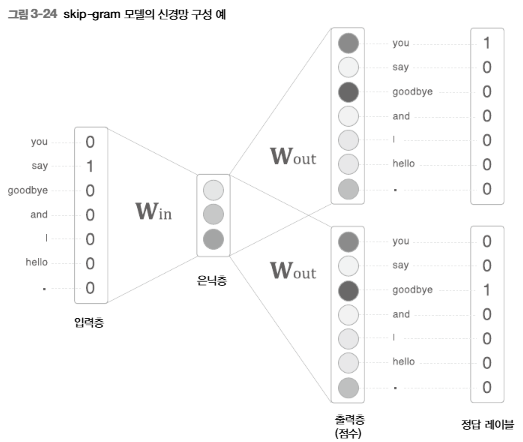   
- 그림에서 보듯 skip-gram 모델의 입력층은 하나
- 한편 출력층은 맥락의 수만큼 존재
- 따라서 각 출력층에서는 (Softmax with Loss 계층 등을 이용해) 개별적으로 손실을 구하고, 이 개별 손실들을 모두 더한 값을 최종 손실로 함   

그러면 skip-gram 모델을 확률 표기로 나타내보면   
중앙 단어(타깃) wt로부터 맥락인 wt-1과 wt+1을 추측하는 경우를 생각   
그러면 skip-gram은 아래 식을 모델링하는 게 됨   
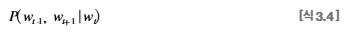   
- 이 식은 'wt가 주어졌을 때 wt-1과 wt+1이 동시에 일어날 확률'을 뜻함
- 여기서 skip-gram 모델에서는 맥락의 단어들 사이에 관련성이 없다고 가정하고 다음과 같이 분해함(정확하게는 '조건부 독립'이라고 가정함)   

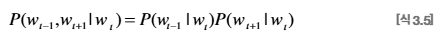   
- 이어서 이 식을 교차 엔트로피 오차에 적용하여 skip-gram 모델의 손실 함수를 유도할 수 있음   

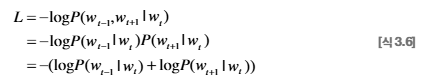   
- 이 유도 과정에서는 라는 로그의 성질을 이용함
- 이 식에서 알 수 있듯, skip-gram 모델의 손실 함수는 맥락별 손실을 구한 다음 모두 더함
- 그리고 이번에도, 위 식은 샘플 데이터 하나짜리 skip-gram의 손실 함수   

이를 말뭉치 전체로 확장하면 skip-gram 모델의 손실 함수는 아래 식이 됨   
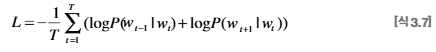   
- 이 식을 CBOW 모델의 식과 비교하면 그 차이가 선명해질 것
- skip-gram 모델은 맥락의 수만큼 추측하기 때문에 그 손실 함수는 각 맥락에서 구한 손실의 총합이어야 함
- 반면, CBOW 모델은 타깃 하나의 손실을 구함   

이상으로 skip-gram 모델의 설명을 마침   
그럼 CBOW 모델과 skip-gram 모델 중 어느 것을 사용해야 하는지? - 그 대답은 skip-gram 모델이라고 할 수 있음   
단어 분산 표현의 정밀도 면에서 skip-gram 모델의 결과가 더 좋은 경우가 많기 때문   

특히 말뭉치가 커질수록 저빈도 단어나 유추 문제의 성능 면에서 skip-gram 모델이 더 뛰어난 경향이 있음   
반면, 학습 속도 면에서는 CBOW 모델이 더 빠름   
skip-gram 모델은 손실을 맥락의 수만큼 구해야 해서 계산 비용이 그만큼 커지기 때문   

> skip-gram 모델은 하나의 단어로부터 그 주변 단어들을 예측함 - 이는 꽤 어려운 문제라고 할 수 있을 것   
> 예컨대 문제를 우리가 직접 푼다고 생각해보면   
> CBOW 모델의 문제라면 'say'라고 쉽게 답할 수 있을 테지만, skip-gram 모델의 문제라면 여러 가지 후보가 떠오를 것   
> 이런 점에서 skip-gram 모델 쪽이 '더 어려운' 문제에 도전한다고 말할 수 있음   
> 그리고 더 어려운 상황에서 단련하는 만큼 skip-gram 모델이 내어 주는 단어의 분산 표현이 더 뛰어날 가능성이 커지는 것   

다행히 CBOW 모델의 구현을 이해할 수 있다면 skip-gram 모델의 구현도 특별히 어려울 게 없음

In [29]:
import sys
sys.path.append('..')
import numpy as np
from common.layers import MatMul, SoftmaxWithLoss


class SimpleSkipGram:
    def __init__(self, vocab_size, hidden_size):
        V, H = vocab_size, hidden_size

        # 가중치 초기화
        W_in = 0.01 * np.random.randn(V, H).astype('f')
        W_out = 0.01 * np.random.randn(H, V).astype('f')

        # 계층 생성
        self.in_layer = MatMul(W_in)
        self.out_layer = MatMul(W_out)
        self.loss_layer1 = SoftmaxWithLoss()
        self.loss_layer2 = SoftmaxWithLoss()

        # 모든 가중치와 기울기를 리스트에 모음
        layers = [self.in_layer, self.out_layer]
        self.params, self.grads = [], []
        for layer in layers:
            self.params += layer.params
            self.grads += layer.grads

        # 인스턴스 변수에 단어의 분산 표현을 저장
        self.word_vecs = W_in

    def forward(self, contexts, target):
        h = self.in_layer.forward(target)
        s = self.out_layer.forward(h)
        l1 = self.loss_layer1.forward(s, contexts[:, 0])
        l2 = self.loss_layer2.forward(s, contexts[:, 1])
        loss = l1 + l2
        return loss

    def backward(self, dout=1):
        dl1 = self.loss_layer1.backward(dout)
        dl2 = self.loss_layer2.backward(dout)
        ds = dl1 + dl2
        dh = self.out_layer.backward(ds)
        self.in_layer.backward(dh)
        return None

### 통계 기반 vs. 추론 기반

지금까지 통계 기반 기법과 추론 기반 기법(특히 word2vec)을 살펴봤음   
학습하는 틀 면에서 두 기법에는 큰 차이가 있었음   
- 통계 기반 기법은 말뭉치의 전체 통계로부터 1회 학습하여 단어의 분산 표현을 얻음   
- 한편, 추론 기반 기법에서는 말뭉치를 일부분씩 여러 번 보면서 학습함(미니배치 학습)   

이번 절에서는 이 학습 방법 외에 두 기법이 또 어떻게 다른지 비교해봄   

먼저, 어휘에 추가할 새 단어가 생겨서 단어의 분산 표현을 갱신해야 하는 상황을 생각해보면   
- 통계 기반 기법에서는 계산을 처음부터 다시 해야 함   
    - 단어의 분산 표현을 조금만 수정하고 싶어도, 동시발생 행렬을 다시 만들고 SVD를 수행하는 일련의 작업을 다시 해야함
- 그에 반해 추론 기반 기법(word2vec)은 매개변수를 다시 학습할 수 있음   
    - 지금까지 학습한 가중치를 초깃값으로 사용해 다시 학습하면 되는데, 이런 특성 덕분에 기존에 학습한 경험을 해치지 않으면서 단어의 분산 표현을 효율적으로 갱신할 수 있음   
    
이 점에서는 확실히 추론 기반 기법(word2vec)이 우세   


그렇다면 두 기법으로 얻는 단어의 분산 표현의 성격이나 정밀도 면에서는 어떤지   
- 분산 표현의 성격에 대해 논하자면, 통계 기반 기법에서는 주로 단어의 유사성이 인코딩됨
- 한편 word2vec(특히 skip-gram 모델)에서는 단어의 유사성은 물론, 한층 복잡한 단어 사이의 패턴까지도 파악되어 인코딩됨
    - word2vec은 "king - man + woman = queen"과 같은 유추 문제를 풀 수 있다는 이야기로 유명한데, 바로 이 특성을 방증하는 예   
    
이런 이유로 추론 기반 기법이 통계 기반 기법보다 정확하다고 흔히들 오해하곤 함   
그러나 실제로 단어의 유사성을 정량 평가해본 결과, 의외로 추론 기반과 통계 기반 기법의 우열을 가릴 수 없었다고 함   

또 다른 중요한 사실로, 추론 기반 기법과 통계 기반 기법은 서로 관련되어 있다고 함   
구체적으로는 skip-gram과 (다음 장에서 다루는) 네거티브 샘플링을 이용한 모델은 모두 말뭉치 전체의 동시발생 행렬(실제로는 살짝 수정한 행렬)에 특수한 행렬 분해를 적용한 것과 같음   
다시 말해, 두 세계는 (특정 조건 하에서) '서로 연결되어 있다'고 할 수 있음   

나아가 word2vec 이후 추론 기반 기법과 통계 기반 기법을 융합한 GloVe 기법이 등장했음   
GloVe의 기본 아이디어는 말뭉치 전체의 통계 정보를 손실 함수에 도입해 미니배치 학습을 하는 것   
이로 인해 두 세계를 명시적으로 융합하는 데 성공했음

## 정리

word2vec은 토마스 미콜로프가 자신의 두 논문에서 제안했음   
이 논문들이 발표된 후 word2vec은 많은 주목을 받았고, 그 유용성을 많은 자연어 처리 과업에서 성과로 입증했음   

다음 장에서는 word2vec의 중요성(특히 word2vec의 전이 학습의 유용성)을 구체적인 예를 들어 설명함   

이번 장에서는 word2vec의 CBOW 모델을 자세히 살펴보고 구현까지 해봤음   
CBOW 모델은 기본적으로 2층 구성의 아주 단순한 신경망   
MatMul 계층과 Softmax with Loss 계층을 사용하여 CBOW 모델을 구축한 다음, 이 모델이 작은 말뭉치를 학습할 수 있음을 확인했음   
안타깝게도 이번 장의 CBOW 모델은 처리 효율 면에서 몇 가지 문제를 안고 있음   
계속해서 다음 장에서는 CBOW 모델을 개선할 예정

### 이번 장에서 배운 내용

- 추론 기반 기법은 추측하는 것이 목적이며, 그 부산물로 단어의 분산 표현을 얻을 수 있음
- word2vec은 추론 기반 기법이며, 단순한 2층 신경망
- word2vec은 skip-gram 모델과 CBOW 모델을 제공함
- CBOW 모델은 여러 단어(맥락)로부터 하나의 단어(타깃)를 추측함
- 반대로 skip-gram 모델은 하나의 단어(타깃)로부터 다수의 단어(맥락)를 추측함
- word2vec은 가중치를 다시 학습할 수 있으므로, 단어의 분산 표현 갱신이나 새로운 단어 추가를 효율적으로 수행할 수 있음